# MITGCM Regional Visualization

**Purpose**: Code for visualizing the spatial evolution of the potential density and velocity field. 

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime, timedelta
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean.cm as cmo
from matplotlib.animation import FuncAnimation, FFMpegWriter
from tqdm import tqdm

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart

Set data analysis parameters

In [3]:
# Set processing parameters
option_depth         = 9          # Specifies the depth level in meter at which the decorrelation data is computed
option_unc           = 1

# Set time and space parameters
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs/paper_figures/supplementary_figs/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'
PATH_calCOFI = ROOT + 'AirSeaCoupling/data/calCOFI/'

# Set plotting parameters 
fontsize = 20
projection = ccrs.PlateCarree(central_longitude=0.0)
xticks = [-123, -122, -121, -120]
yticks = [33.25, 33.50, 33.75, 34.00, 34.25, 34.50, 34.75,]
resolution = "10m"
bounds = np.arange(0,360+40,40)
lon_min = -123
lon_max = -120
lat_min = 33
lat_max = 35

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

Load mitgcm data netcdf files 

In [4]:
#-------------------------------------------------------#
# Regional Density and Velocity Data
#-------------------------------------------------------#
filename_tsd = PATH + "mitgcm_intermediate_data_TSD_hrly_map_depth_" + str(option_depth) + "m.nc"
filename_vel = PATH + "mitgcm_intermediate_data_vel_hrly_map_depth_" + str(option_depth) + "m.nc"
nc_tsd = Dataset(filename_tsd, 'r')
nc_vel = Dataset(filename_vel, 'r')

# Extract data variables
depth = nc_tsd.variables['Depth'][:]
lon = nc_tsd.variables['lon'][:]
lat = nc_tsd.variables['lat'][:]
time =  num2date(nc_tsd.variables['time'][:], nc_tsd.variables['time'].units)

sig = nc_tsd.variables['SIG'][:]
u = nc_vel.variables['u'][:]
v = nc_vel.variables['v'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

#-------------------------------------------------------#
# Decorrelation scale Data
#-------------------------------------------------------#
filename_decor  = PATH + "/mitgcm_regional_temporal_scale_density_depth_" + str(option_depth) + "m_unc.npz"

# Load data 
ds_decor   = np.load(filename_decor, allow_pickle=True)

# Extract data variables
Lt_days       = ds_decor['Lt_days']         # Units: days
Lt_stdm_days  = ds_decor['Lt_stdm_days']    # Units: days
lon_decor     = ds_decor['lon']             
lat_decor     = ds_decor['lat']

Read in bathymetry data

In [5]:
# Load bathymetry data 
filename = PATH_bathy + "topo_25.1.nc"
ds_bathy = xr.open_dataset(filename, engine="netcdf4")

# Extract data variables
lon_b = ds_bathy["lon"]  # Longitude
lat_b = ds_bathy["lat"]  # Latitude
bathy = ds_bathy["z"]    # Elevation/Bathymetry

# Convert convesion of longitude (neg from the prime meridian to positive definite wrapping around the earth)
lon_n = lon_b % 360

# Set max and min values 
lon_min = lon_bnds[0]
lon_max = lon_bnds[1]
lat_min = lat_bnds[0]
lat_max = lat_bnds[1]

# Extract data from bathymetry 
lon_grid = lon_n[(lon_n >= lon_min) & (lon_n <= lon_max)]
lat_grid = lat_b[(lat_b >= lat_min) & (lat_b <= lat_max)]
bathy_grid   = bathy[(lat_b >= lat_min) & (lat_b <= lat_max),(lon_n >= lon_min) & (lon_n <= lon_max)]

Set the locations of each cce mooring

In [6]:
#--- CCE 1 ---# 
lon1 = -122.52233 
lat1 = 33.457

#--- CCE 2 ---# 
lon2 = -120.8042 
lat2 = 34.3075

#--- CCE 3 ---# 
lon3 = -120.53816
lat3 = 34.448512

Read in CalCOFI stations

In [7]:
# Load CalCOFI csv file 
filename = PATH_calCOFI + "CalCOFIStationOrder.csv"
calCOFI_data = np.genfromtxt(
    filename,
    delimiter=",",
    skip_header=1,
    usecols=(1, 3, 7, 11),
    invalid_raise=False
)

# Grab stations on line 80.0
calCOFI_line80 = calCOFI_data[calCOFI_data[:, 0] == 80.0] 

# Parse data into separate arrays
calCOFI_stn   = calCOFI_line80[:, 0]
calCOFI_lat   = calCOFI_line80[:, 1]
calCOFI_lon   = calCOFI_line80[:, 2]
calCOFI_depth = calCOFI_line80[:, 3]

Compute the relative uncertainty and mask grid point with a decorrelation scale less than twice its standard error

In [8]:
# Set noise to signal ratio criteria
ns = 10 / 10

# Compute spatial means 
Lt_rho_spatial_mean = np.mean(Lt_days) 

# Compute the relative uncertainty
Lt_rho_rel_unc = Lt_stdm_days / (Lt_days - Lt_rho_spatial_mean)

# Mask not statistically significant grid points
Lt_rho_mask = np.ma.getmask(np.ma.masked_greater_equal(Lt_rho_rel_unc, (ns)))

# Create a mask array where non-significant points = 1, others = NaN
rho_mask = np.where(Lt_rho_mask, 1, np.nan)

Plot the spatial map of the decorrelation time scale 

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


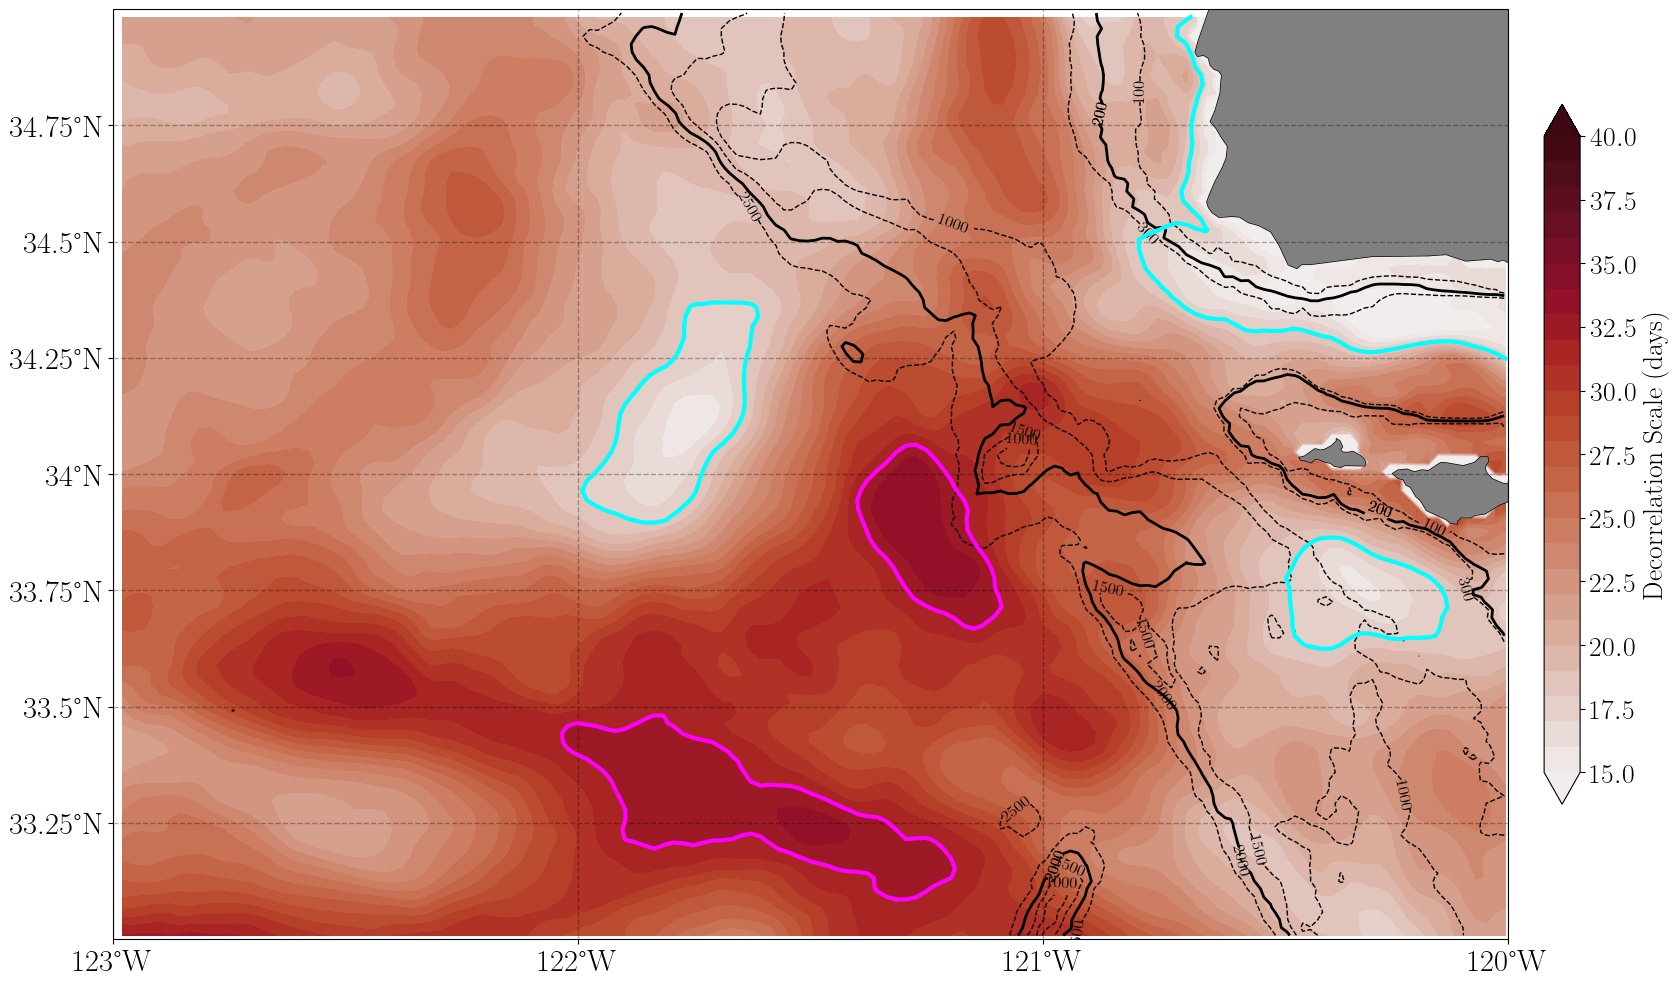

In [9]:
# Set plotting parameters 
levels = np.arange(15,40 + 1,1) 
levels_decor = [18, 32]

# Create figure
fig, axes = plt.subplots(1,1, figsize=(18, 20), subplot_kw={"projection": projection})

# Set figure axes 
cart.set_subplots(axes, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot temporal decorrelation scale
cf = axes.contourf(
    lon, lat, Lt_days, levels=levels,
    transform=ccrs.PlateCarree(),
    cmap=cmo.amp,  
    shading="auto", 
    extend = 'both'
)

# ---------------------
# Plot and filter decorrelation contours (robust version)
# ---------------------

levels_decor = [18, 32]
min_points = 50

# 1. Create contours (we immediately extract segments and remove artist)
cs = axes.contour(
    lon, lat, Lt_days,
    levels=levels_decor,
    transform=ccrs.PlateCarree()
)

# 2. Filter segments using allsegs (stable representation)
filtered_segments = []
filtered_levels = []

for i, seg_list in enumerate(cs.allsegs):
    good_segs = [seg for seg in seg_list if len(seg) > min_points]

    if len(good_segs) > 0:
        filtered_segments.append(good_segs)
        filtered_levels.append(levels_decor[i])

# 3. Remove original contour object
cs.remove()

# 4. Re-plot only filtered segments
for lvl_segs, lvl in zip(filtered_segments, filtered_levels):

    color = 'cyan' if lvl == 18 else 'magenta'

    for seg in lvl_segs:
        axes.plot(
            seg[:, 0],
            seg[:, 1],
            transform=ccrs.PlateCarree(),
            color=color,
            linewidth=3,
            zorder=6
        )

# Plot depth contour lines
level_innershelf = np.arange(100,300+100,100)
levels_midshelf = np.arange(1000,3000,500)
contour1 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=2, linestyles='solid')
contour3 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

# Set grid ticks 
cart.set_grid_ticks(
    axes,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="k",
)

# Create colormap
cax = plt.axes([0.92, 0.33, 0.02, 0.35])
cart.set_cbar(
    cf,
    cax,
    fig,
    orientation="vertical",
    extend="both",
    cbar_label=r'Decorrelation Scale (days)',
    nbins=10,
    fontsize=20,
    cbar_ticks=[],
    task="regular",
)

# Show the plot
plt.show()

In [10]:
time_dt[0]

datetime.datetime(2015, 12, 27, 3, 0)

Set user options for the animation

In [41]:
# ---------------------
# User options
# ---------------------
season = "winter"   # "winter" or "spring"
num_days = 120

# Define start dates
if season == "winter":
    start_date = datetime(2016, 12, 1)
elif season == "spring":
    start_date = datetime(2016, 3, 1)
else:
    raise ValueError("season must be 'winter' or 'spring'")

# Duration: 120 days
end_date = start_date + timedelta(days=num_days)

# Find indices within this window
time_mask = (time_dt >= start_date) & (time_dt < end_date)
time_indices = np.where(time_mask)[0]

print(f"Selected {len(time_indices)} hourly time steps")

# ---------------------
# Frame rate control (NO STRIDE)
# ---------------------
target_duration_sec = 90   # 60 for 1 min, 90 for 1.5 min

num_frames = len(time_indices)

fps = 24 #int(np.ceil(num_frames / target_duration_sec))

print(f"Total frames: {num_frames}")
print(f"Using fps: {fps}")
print(f"Video duration: {num_frames / fps:.1f} seconds")

Selected 2880 hourly time steps
Total frames: 2880
Using fps: 24
Video duration: 120.0 seconds


Create an animation of the potential density field wth velocity vectors overlaid

Rendering frames: 100%|██████████| 96/96 [00:45<00:00,  2.12it/s]


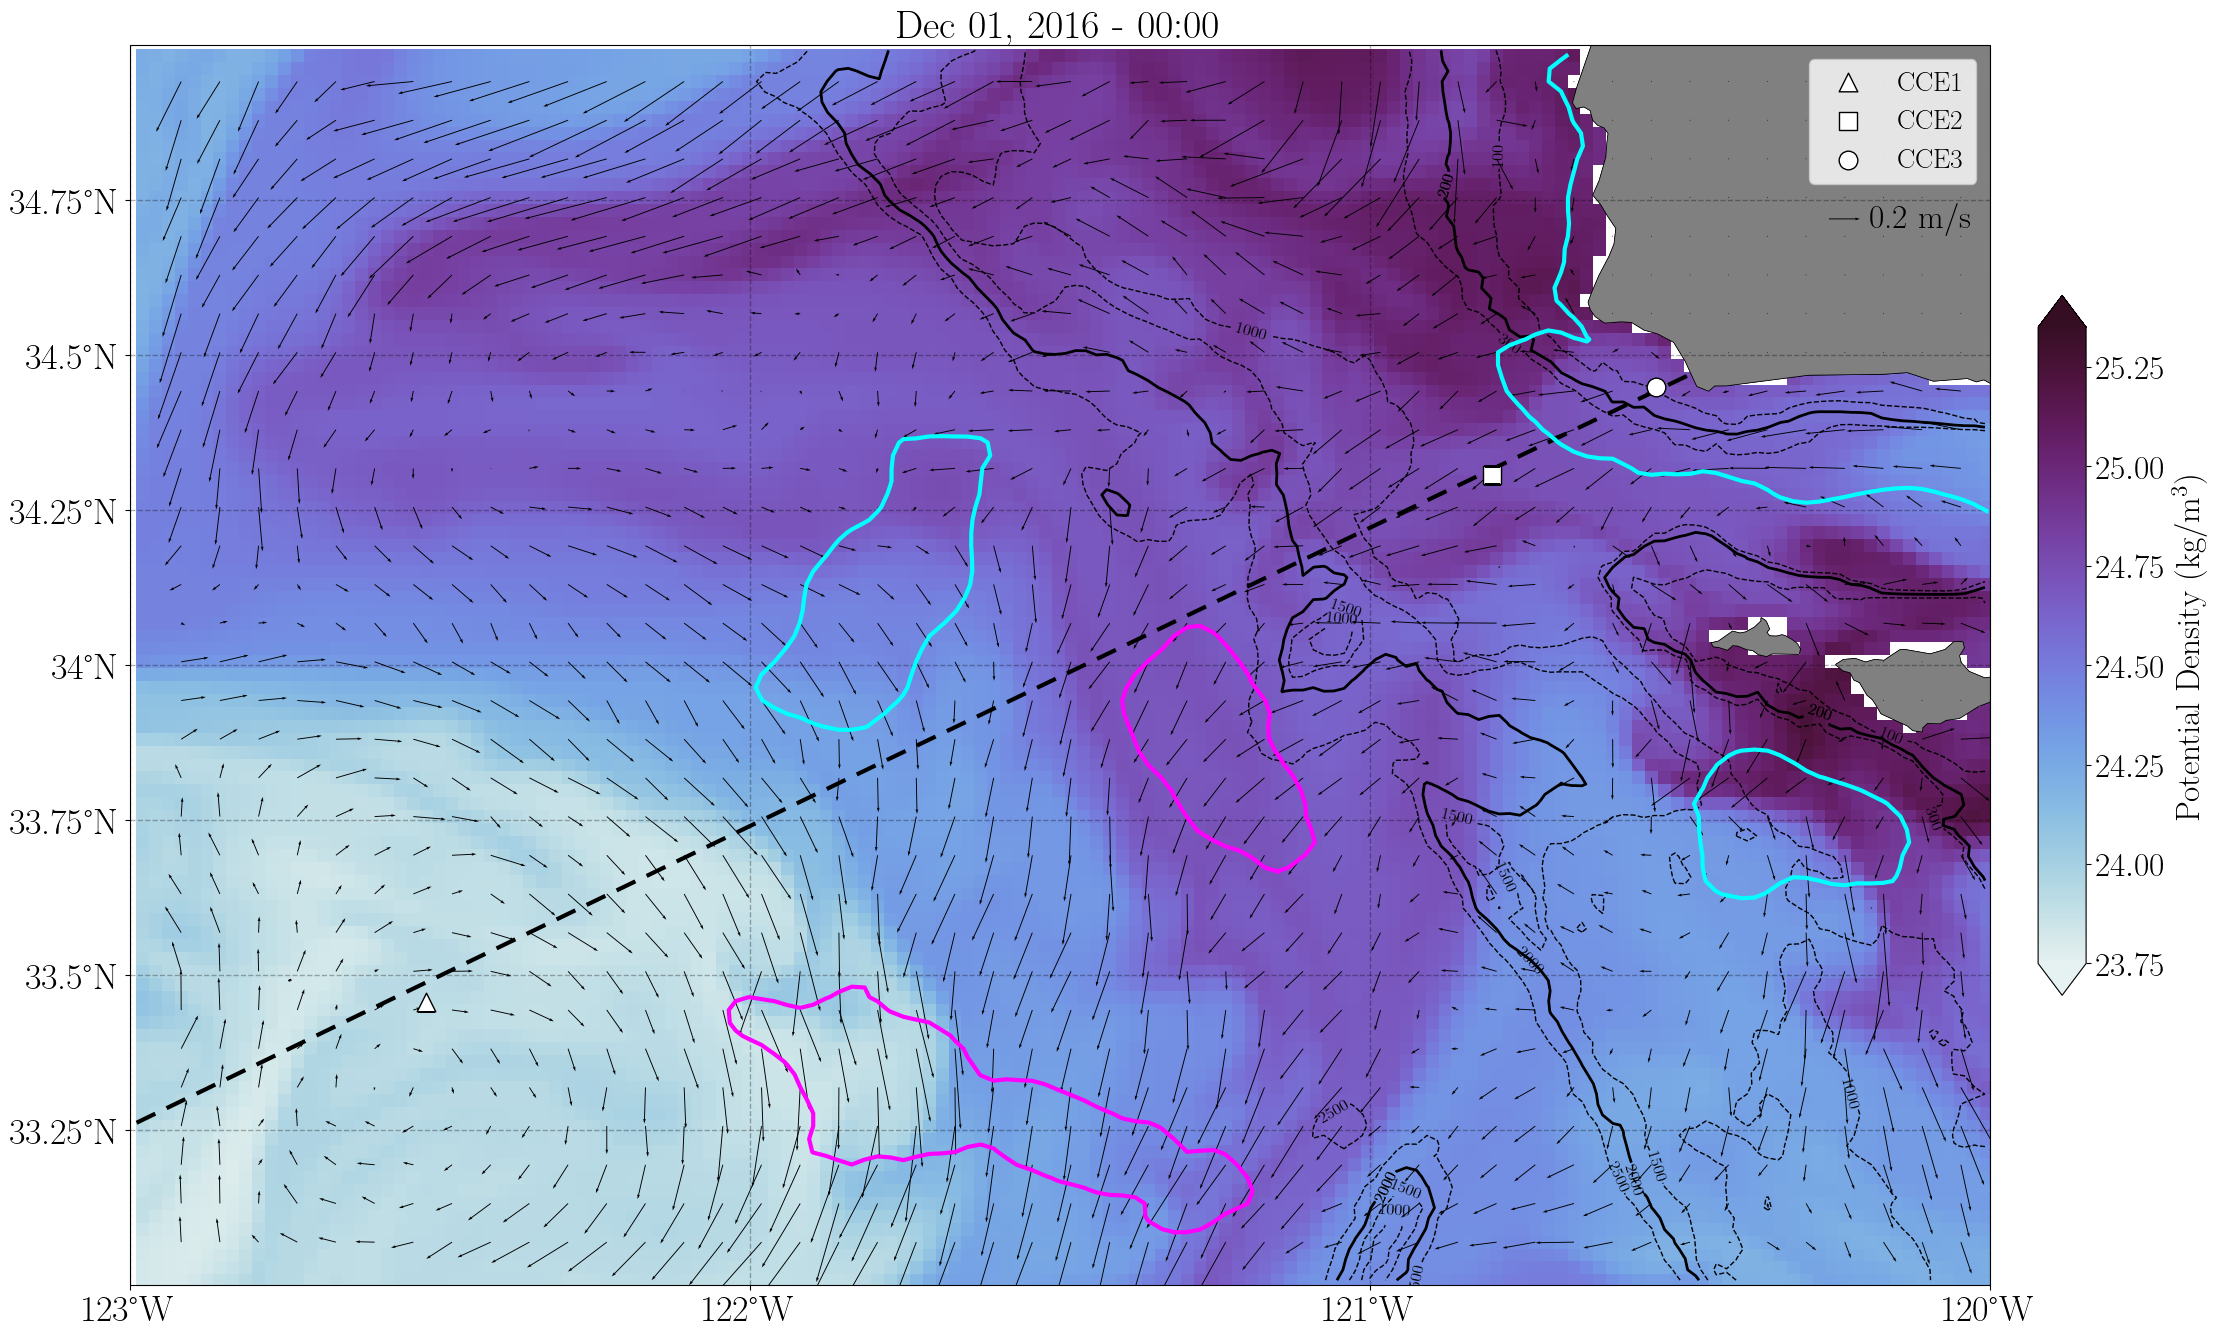

In [33]:
# Set plotting parameters
fontsize = 24
levels = np.arange(24, 25.25+0.04, 0.04)
levels_decor = [18, 32]
cmap = cmo.dense 
frame_indices = time_indices
num_frames = len(frame_indices)
fmt = {16: '16 days', 38: '38 days'}

# Create figure
fig, ax = plt.subplots(1,1, figsize=(24, 20), subplot_kw={"projection": projection})

# Set figure axes 
cart.set_subplots(ax, projection, resolution, lon_min=-124, lon_max=-119, lat_min=32.50, lat_max=35)

# Draw map features
cart.set_subplots(ax, projection, resolution,
                    lon_min=lon_min, lon_max=lon_max,
                    lat_min=lat_min, lat_max=lat_max)

# Set Grid
cart.set_grid_ticks(
    ax,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=fontsize+2,
    color="black",
)

# Plot potential density at the first time step to set colorbar
mesh = ax.pcolormesh(
    lon, lat, sig[0, :, :],
    transform=ccrs.PlateCarree(),
    cmap=cmap, 
    vmin=23.75, vmax= 25.35
)

# Plot Velocity vectors (subsampled spatially)
quiv = ax.quiver(
    lon[::3], lat[::3],
    u[0, ::3, ::3],
    v[0, ::3, ::3],
    transform=ccrs.PlateCarree(),
    scale=12, width=0.0005, color='k', zorder=5
)

# Set a quiver key
qk = ax.quiverkey(
    quiv,
    X=0.93, Y=0.86,             # position in axes coordinates (0–1)
    U=0.2,                      # reference velocity (choose something meaningful)
    label='0.2 m/s',            # label text
    labelpos='E',               # label position: E, W, N, S
    coordinates='axes',
    fontproperties={'size': fontsize}
)

# Plot Bathymetry 
contour1 = ax.contour(lon_grid, lat_grid, -bathy_grid,
                        levels=np.arange(1000,3000,500),
                        colors='black', linewidths=1, linestyles='dashed')

contour2 = ax.contour(lon_grid, lat_grid, -bathy_grid,
                        levels=[2000], colors='black', linewidths=2)

contour3 = ax.contour(lon_grid, lat_grid, -bathy_grid,
                        levels=np.arange(100,300+100,100),
                        colors='black', linewidths=1, linestyles='dashed')

contour4 = ax.contour(lon_grid, lat_grid, -bathy_grid,
                        levels=[200], colors='black', linewidths=2)
plt.clabel(contour1, fontsize=12) 
plt.clabel(contour2, fontsize=12) 
plt.clabel(contour3, fontsize=12) 
plt.clabel(contour4, fontsize=12)

# ---------------------
# Plot and filter decorrelation contours (robust version)
# ---------------------
levels_decor = [18, 32]
min_points = 50

# 1. Create contours (we immediately extract segments and remove artist)
cs = ax.contour(
    lon, lat, Lt_days,
    levels=levels_decor,
    transform=ccrs.PlateCarree()
)

# 2. Filter segments using allsegs (stable representation)
filtered_segments = []
filtered_levels = []

for i, seg_list in enumerate(cs.allsegs):
    good_segs = [seg for seg in seg_list if len(seg) > min_points]

    if len(good_segs) > 0:
        filtered_segments.append(good_segs)
        filtered_levels.append(levels_decor[i])

# 3. Remove original contour object
cs.remove()

# 4. Re-plot only filtered segments
for lvl_segs, lvl in zip(filtered_segments, filtered_levels):

    color = 'cyan' if lvl == 18 else 'magenta'

    for seg in lvl_segs:
        ax.plot(
            seg[:, 0],
            seg[:, 1],
            transform=ccrs.PlateCarree(),
            color=color,
            linewidth=3,
            zorder=6
        )

# # Label the contour lines
# ax.clabel(
#     decor_contours,
#     fmt=fmt,
#     fontsize=16,
#     inline=True
# )

#--- CCE Moorings ---# 

# Plot the mooring point
ax.scatter(
    lon1, lat1, 
    color='w',
    edgecolor='black', marker='^', s=180,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE1'
)

# Plot the mooring point
ax.scatter(
    lon2, lat2, 
    color='w',  # color from the same colormap
    edgecolor='black', marker='s', s=180,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE2'
)

# Plot the mooring point
ax.scatter(
    lon3, lat3, 
    color= 'w',  
    edgecolor='black', marker='o', s=180,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE3'
)

# Plot Line 80 CalCOFI Stations
ax.plot(
    calCOFI_lon % 360, calCOFI_lat,
    color='k',
    linestyle=(0, (5, 3)),   # (offset, (dash_length, gap_length))
    linewidth=3,
    transform=ccrs.PlateCarree(),
)

# Set up a legend
ax.legend(loc='upper right')

# Create colormap
cax = plt.axes([0.92, 0.33, 0.02, 0.35])
cbar = fig.colorbar(mesh, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'Potential Density (kg/m$^3$)',fontsize=fontsize)
cbar.set_ticks(np.arange(23.75,25.25+0.25,0.25))
cbar.ax.tick_params(labelsize=fontsize)

# Set mesh variable
mesh = None

# ---------------------
# Animation update function
# ---------------------
def update(frame, sig, u, v, time_dt):

    global mesh

    # Set frame indice
    idx = frame_indices[frame] 

    # Remove old mesh ONLY
    if mesh is not None:
        mesh.remove()

    # Title
    ax.set_title(time_dt[idx].strftime('%b %d, %Y - %H:%M'), fontsize=fontsize+5)

    # Plot potential density
    mesh = ax.pcolormesh(
        lon, lat, sig[idx, :, :],
        transform=ccrs.PlateCarree(),
        cmap=cmap, 
        vmin=24, vmax= 25.25
    )

    # Plot Velocity vectors (subsampled spatially)
    quiv.set_UVC(u[idx, ::3, ::3], v[idx, ::3, ::3])

    return []

# ---------------------
# Create animation
# ---------------------
ani = FuncAnimation(
    fig,
    update,
    frames=num_frames,
    fargs=(sig, u, v, time_dt),
    blit=False
)

# ---------------------
# Save animation with progress bar
# ---------------------
writer = FFMpegWriter(
    fps=fps,
    metadata={'artist': 'Potential Density'}
)

output_file = PATH_figs + f'sig_variability_{season}_2016.mp4'

with writer.saving(fig, output_file, dpi=120):

    for frame in tqdm(range(num_frames), desc="Rendering frames"):

        update(frame, sig, u, v, time_dt)
        writer.grab_frame()

Compute magnitude of the spatial gradients of the density

In [ ]:
#---------------------------# 
# Compute grid spacing in meters for the MITgcm grid
#---------------------------# 

# Earth radius (m)
R = 6371000  

# Convert to radians
lat_rad = np.deg2rad(lat)
lon_rad = np.deg2rad(lon)

# Compute spacing
dlat = np.gradient(lat_rad)                # (lat,)
dlon = np.gradient(lon_rad)                # (lon,)

# Convert to meters
dy = R * dlat                              # (lat,)
dx = R * np.cos(lat_rad)[:, None] * dlon   # (lat, lon)

#---------------------------# 
# Compute spatial gradients 
#---------------------------#

# Compute gradients (axis: 1=lat, 2=lon)
dsig_dy = np.gradient(sig, axis=1) / dy[None, :, None]
dsig_dx = np.gradient(sig, axis=2) / dx[None, :, :]

# Gradient magnitude
sig_grad_mag = np.sqrt(dsig_dx**2 + dsig_dy**2)

# Compute time mean and variance
sig_grad_mag_mean = np.mean(sig_grad_mag, axis=0) 
sig_grad_mag_var = np.var(sig_grad_mag, ddof=1,axis=0) 


Create an animation of the horizontal spatial gradient of potential density field wth velocity vectors overlaid

Rendering frames: 100%|██████████| 2880/2880 [18:44<00:00,  2.56it/s]


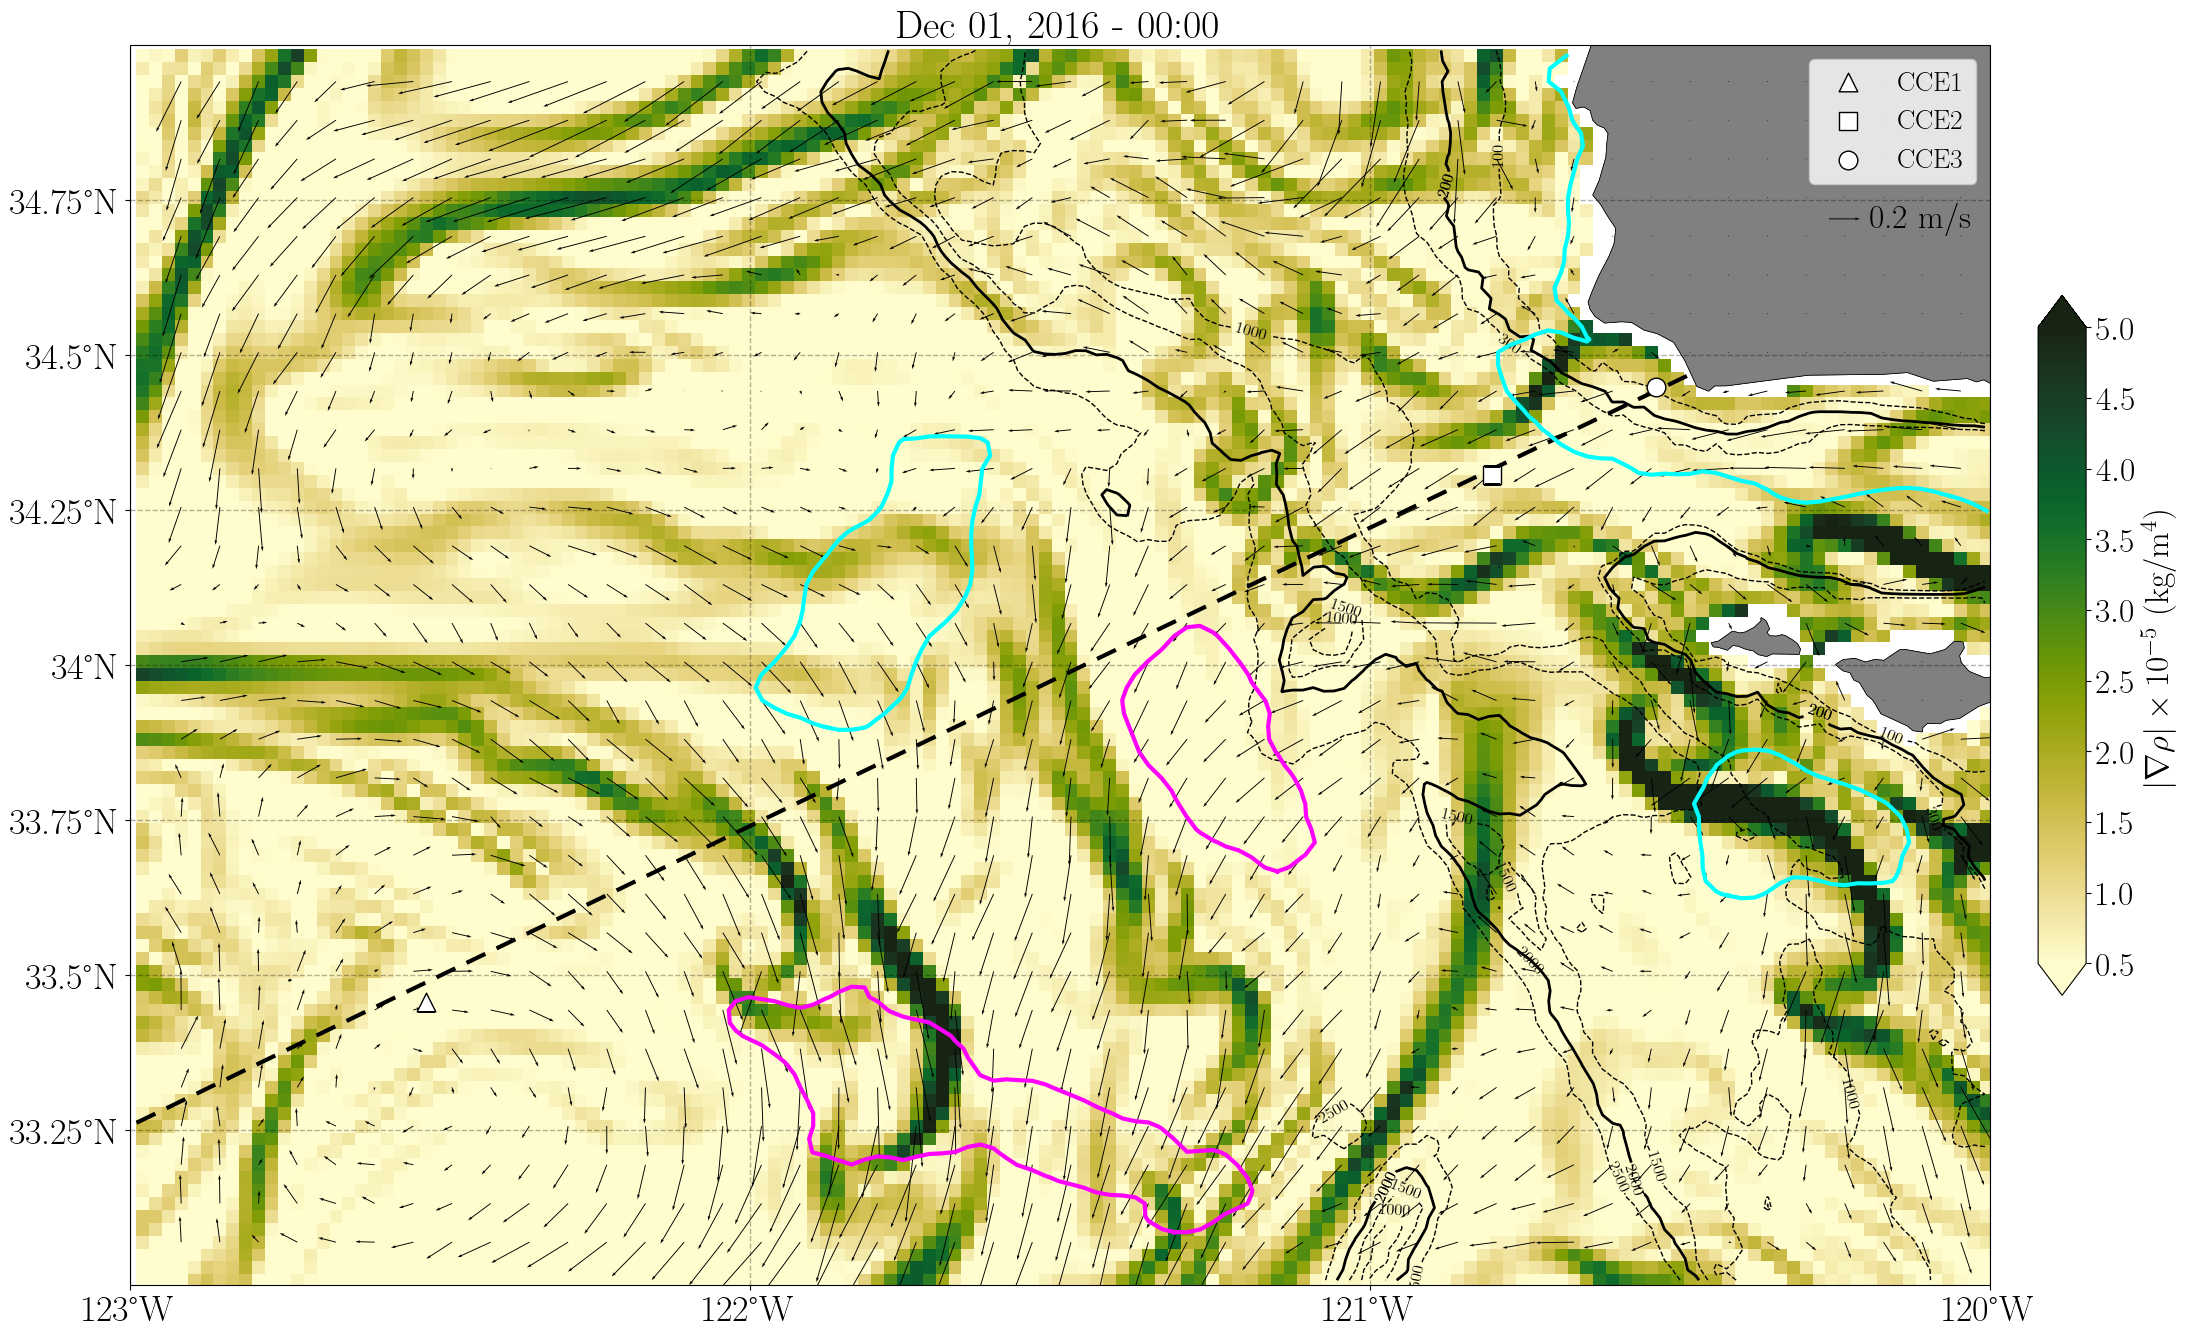

In [42]:
# Set plotting parameters
fontsize = 24
levels_decor = [18, 32]
cmap = cmo.speed 
frame_indices = time_indices
num_frames = len(frame_indices)
fmt = {16: '16 days', 38: '38 days'}

# Create figure
fig, ax = plt.subplots(1,1, figsize=(24, 20), subplot_kw={"projection": projection})

# Set figure axes 
cart.set_subplots(ax, projection, resolution, lon_min=-124, lon_max=-119, lat_min=32.50, lat_max=35)

# Draw map features
cart.set_subplots(ax, projection, resolution,
                    lon_min=lon_min, lon_max=lon_max,
                    lat_min=lat_min, lat_max=lat_max)

# Set Grid
cart.set_grid_ticks(
    ax,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=fontsize+2,
    color="black",
)

# Plot potential density at the first time step to set colorbar
mesh = ax.pcolormesh(
    lon, lat, sig_grad_mag[0, :, :]*10**5,
    transform=ccrs.PlateCarree(),
    cmap=cmap, 
    vmin=0.5, vmax= 5
)

# Plot Velocity vectors (subsampled spatially)
quiv = ax.quiver(
    lon[::3], lat[::3],
    u[0, ::3, ::3],
    v[0, ::3, ::3],
    transform=ccrs.PlateCarree(),
    scale=12, width=0.0005, color='k', zorder=5
)

# Set a quiver key
qk = ax.quiverkey(
    quiv,
    X=0.93, Y=0.86,             # position in axes coordinates (0–1)
    U=0.2,                      # reference velocity (choose something meaningful)
    label='0.2 m/s',            # label text
    labelpos='E',               # label position: E, W, N, S
    coordinates='axes',
    fontproperties={'size': fontsize}
)

# Plot Bathymetry 
contour1 = ax.contour(lon_grid, lat_grid, -bathy_grid,
                        levels=np.arange(1000,3000,500),
                        colors='black', linewidths=1, linestyles='dashed')

contour2 = ax.contour(lon_grid, lat_grid, -bathy_grid,
                        levels=[2000], colors='black', linewidths=2)

contour3 = ax.contour(lon_grid, lat_grid, -bathy_grid,
                        levels=np.arange(100,300+100,100),
                        colors='black', linewidths=1, linestyles='dashed')

contour4 = ax.contour(lon_grid, lat_grid, -bathy_grid,
                        levels=[200], colors='black', linewidths=2)
plt.clabel(contour1, fontsize=12) 
plt.clabel(contour2, fontsize=12) 
plt.clabel(contour3, fontsize=12) 
plt.clabel(contour4, fontsize=12)

# ---------------------
# Plot and filter decorrelation contours (robust version)
# ---------------------
levels_decor = [18, 32]
min_points = 50

# 1. Create contours (we immediately extract segments and remove artist)
cs = ax.contour(
    lon, lat, Lt_days,
    levels=levels_decor,
    transform=ccrs.PlateCarree()
)

# 2. Filter segments using allsegs (stable representation)
filtered_segments = []
filtered_levels = []

for i, seg_list in enumerate(cs.allsegs):
    good_segs = [seg for seg in seg_list if len(seg) > min_points]

    if len(good_segs) > 0:
        filtered_segments.append(good_segs)
        filtered_levels.append(levels_decor[i])

# 3. Remove original contour object
cs.remove()

# 4. Re-plot only filtered segments
for lvl_segs, lvl in zip(filtered_segments, filtered_levels):

    color = 'cyan' if lvl == 18 else 'magenta'

    for seg in lvl_segs:
        ax.plot(
            seg[:, 0],
            seg[:, 1],
            transform=ccrs.PlateCarree(),
            color=color,
            linewidth=3,
            zorder=6
        )

#--- CCE Moorings ---# 

# Plot the mooring point
ax.scatter(
    lon1, lat1, 
    color='w',
    edgecolor='black', marker='^', s=180,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE1'
)

# Plot the mooring point
ax.scatter(
    lon2, lat2, 
    color='w',  # color from the same colormap
    edgecolor='black', marker='s', s=180,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE2'
)

# Plot the mooring point
ax.scatter(
    lon3, lat3, 
    color= 'w',  
    edgecolor='black', marker='o', s=180,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE3'
)

# Plot Line 80 CalCOFI Stations
ax.plot(
    calCOFI_lon % 360, calCOFI_lat,
    color='k',
    linestyle=(0, (5, 3)),   # (offset, (dash_length, gap_length))
    linewidth=3,
    transform=ccrs.PlateCarree(),
)

# Set up a legend
ax.legend(loc='upper right')

# Create colormap
cax = plt.axes([0.92, 0.33, 0.02, 0.35])
cbar = fig.colorbar(mesh, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'$\lvert\nabla \rho\rvert \times 10^{-5}$ (kg/m$^4$)',fontsize=fontsize)
cbar.set_ticks(np.arange(0.5,5+0.5,0.5))
cbar.ax.tick_params(labelsize=fontsize)

# Set mesh variable
mesh = None

# ---------------------
# Animation update function
# ---------------------
def update(frame, sig, u, v, time_dt):

    global mesh

    # Set frame indice
    idx = frame_indices[frame] 

    # Remove old mesh ONLY
    if mesh is not None:
        mesh.remove()

    # Title
    ax.set_title(time_dt[idx].strftime('%b %d, %Y - %H:%M'), fontsize=fontsize+5)

    # Plot potential density
    mesh = ax.pcolormesh(
        lon, lat, sig_grad_mag[idx, :, :]*10**5,
        transform=ccrs.PlateCarree(),
        cmap=cmap, 
        vmin=0.5, vmax= 5
    )

    # Plot Velocity vectors (subsampled spatially)
    quiv.set_UVC(u[idx, ::3, ::3], v[idx, ::3, ::3])

    return []

# ---------------------
# Create animation
# ---------------------
ani = FuncAnimation(
    fig,
    update,
    frames=num_frames,
    fargs=(sig, u, v, time_dt),
    blit=False
)

# ---------------------
# Save animation with progress bar
# ---------------------
writer = FFMpegWriter(
    fps=fps,
    metadata={'artist': 'Potential Density'}
)

output_file = PATH_figs + f'grad_sig_variability_{season}_2016.mp4'

with writer.saving(fig, output_file, dpi=120):

    for frame in tqdm(range(num_frames), desc="Rendering frames"):

        update(frame, sig, u, v, time_dt)
        writer.grab_frame()

Create an animation with contourf (more time intensive)

In [ ]:
# Set plotting parameters
fontsize = 24
levels = np.arange(24, 25.25+0.04, 0.04)
levels_decor = [18, 32]
cmap = cmo.dense 
frame_indices = time_indices
num_frames = len(frame_indices)
fmt = {16: '16 days', 38: '38 days'}

# Create figure
fig, ax = plt.subplots(1,1, figsize=(24, 20), subplot_kw={"projection": projection})

# Set figure axes 
cart.set_subplots(ax, projection, resolution, lon_min=-124, lon_max=-119, lat_min=32.50, lat_max=35)

# Draw map features
cart.set_subplots(ax, projection, resolution,
                    lon_min=lon_min, lon_max=lon_max,
                    lat_min=lat_min, lat_max=lat_max)

# Set Grid
cart.set_grid_ticks(
    ax,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=fontsize+2,
    color="black",
)

# Plot potential density at the first time step to set colorbar
cf = ax.contourf(
    lon, lat, sig[0, :, :],
    levels=levels,
    transform=ccrs.PlateCarree(),
    cmap=cmap, 
    extend='both'
)

# Plot Velocity vectors (subsampled spatially)
# quiv = ax.quiver(
#     lon[::3], lat[::3],
#     u[0, ::3, ::3],
#     v[0, ::3, ::3],
#     transform=ccrs.PlateCarree(),
#     scale=10, width=0.001, color='k', zorder=5
# )

# Plot Bathymetry 
contour1 = ax.contour(lon_grid, lat_grid, -bathy_grid,
                        levels=np.arange(1000,3000,500),
                        colors='black', linewidths=1, linestyles='dashed')

contour2 = ax.contour(lon_grid, lat_grid, -bathy_grid,
                        levels=[2000], colors='black', linewidths=2)

contour3 = ax.contour(lon_grid, lat_grid, -bathy_grid,
                        levels=np.arange(100,300+100,100),
                        colors='black', linewidths=1, linestyles='dashed')

contour4 = ax.contour(lon_grid, lat_grid, -bathy_grid,
                        levels=[200], colors='black', linewidths=2)
plt.clabel(contour1, fontsize=12) 
plt.clabel(contour2, fontsize=12) 
plt.clabel(contour3, fontsize=12) 
plt.clabel(contour4, fontsize=12)

# ---------------------
# Plot and filter decorrelation contours (robust version)
# ---------------------

levels_decor = [18, 32]
min_points = 50

# 1. Create contours (we immediately extract segments and remove artist)
cs = axes.contour(
    lon, lat, Lt_days,
    levels=levels_decor,
    transform=ccrs.PlateCarree()
)

# 2. Filter segments using allsegs (stable representation)
filtered_segments = []
filtered_levels = []

for i, seg_list in enumerate(cs.allsegs):
    good_segs = [seg for seg in seg_list if len(seg) > min_points]

    if len(good_segs) > 0:
        filtered_segments.append(good_segs)
        filtered_levels.append(levels_decor[i])

# 3. Remove original contour object
cs.remove()

# 4. Re-plot only filtered segments
for lvl_segs, lvl in zip(filtered_segments, filtered_levels):

    color = 'cyan' if lvl == 18 else 'magenta'

    for seg in lvl_segs:
        axes.plot(
            seg[:, 0],
            seg[:, 1],
            transform=ccrs.PlateCarree(),
            color=color,
            linewidth=3,
            zorder=6
        )

# # Label the contour lines
# ax.clabel(
#     decor_contours,
#     fmt=fmt,
#     fontsize=16,
#     inline=True
# )

# Create colormap
cax = plt.axes([0.92, 0.33, 0.02, 0.35])
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='max') 
cbar.set_label(r'Potential Density (kg/m$^3$)',fontsize=fontsize)
cbar.set_ticks(np.arange(24.00,25.25+0.25,0.25))
cbar.ax.tick_params(labelsize=fontsize)

# Set contourf_obj variable
contourf_obj = None

# ---------------------
# Animation update function
# ---------------------
def update(frame, sig, u, v, time_dt):

    global contourf_obj

    # Set frame indice
    idx = frame_indices[frame] 

    # Remove old contourf ONLY
    if contourf_obj is not None:
        for artist in contourf_obj.collections if hasattr(contourf_obj, "collections") else []:
            artist.remove()

    # Title
    ax.set_title(time_dt[idx].strftime('%b %d, %Y - %H:%M'), fontsize=fontsize+5)

    # Plot potential density
    contourf_obj = ax.contourf(
        lon, lat, sig[idx, :, :],
        levels=levels,
        transform=ccrs.PlateCarree(),
        cmap=cmap, 
        extend='both'
    )

    # Plot Velocity vectors (subsampled spatially)
    #quiv.set_UVC(u[idx, ::3, ::3], v[idx, ::3, ::3])

    return []

# ---------------------
# Create animation
# ---------------------
ani = FuncAnimation(
    fig,
    update,
    frames=num_frames,
    fargs=(sig, u, v, time_dt),
    blit=False
)

# ---------------------
# Save animation with progress bar
# ---------------------
writer = FFMpegWriter(
    fps=fps,
    metadata={'artist': 'Potential Density'}
)

output_file = PATH_figs + f'sig_variability_{season}_2016.mp4'

with writer.saving(fig, output_file, dpi=120):

    for frame in tqdm(range(num_frames), desc="Rendering frames"):

        update(frame, sig, u, v, time_dt)
        writer.grab_frame()